<a href="https://colab.research.google.com/github/danish2k04/Getting-into-Pytorch-Deep-Learning/blob/main/LinearRegressionModel2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

Create Device Agnostic code

This means if we have got access to a GPU, our code will use it(for potentially faster comptutation).

If GPU is not availabe, then code will use CPU

In [2]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

1.Creating data

In [3]:
# create known parameter
weight = 0.7
bias = 0.3

# creating data
start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
Y = weight * X + bias

X[:5], Y[:5], len(X), len(Y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]),
 50,
 50)

2. Creating Trainging and Tesing Data

In [4]:
split = int(len(X)*0.8)
X_train, Y_train = X[:split], Y[:split]
X_test, Y_test = X[split:], Y[split:]

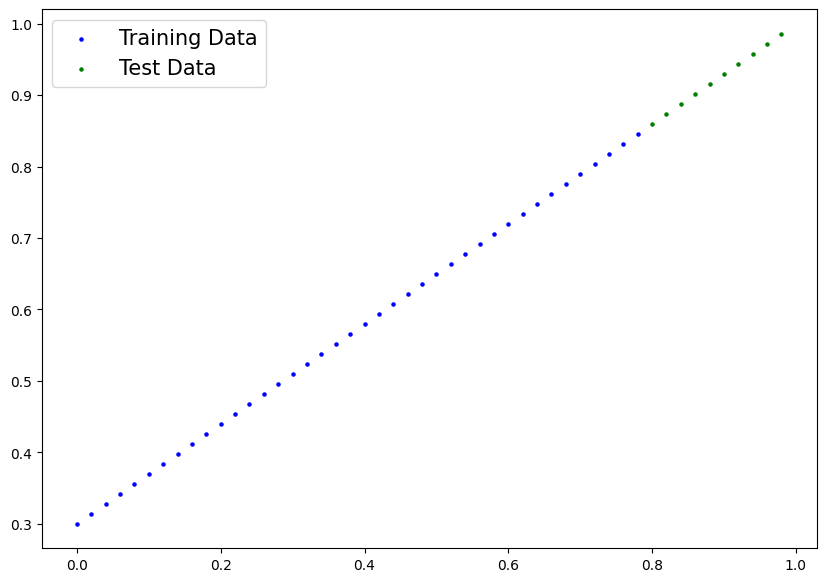

In [5]:
def plot_prediction(train_data = X_train,
                    train_label = Y_train,
                    test_data = X_test,
                    test_label = Y_test,
                    prediction = None):
  plt.figure(figsize=(10, 7))

  #plot training data in blue
  plt.scatter(train_data, train_label, c="b", s=5 , label="Training Data")

  # plt test data in green
  plt.scatter(test_data, test_label, c="g", s=5, label="Test Data")

  # plot prediction in red
  if prediction is not None:
    plt.scatter(test_data, prediction, c="r", s=5, label="Predictions")

  plt.legend(prop={"size":15});

plot_prediction()

3. Creating a model Class with defining Parameters

In [6]:
from tempfile import SpooledTemporaryFile
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    #Use nn.linear
    self.linear_layer = nn.Linear(in_features=1,
                                   out_features=1)

  def forward(self, x: torch.tensor) -> torch.tensor:
    return self.linear_layer(x)

# seet the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModel()
model_1, model_1.state_dict()

(LinearRegressionModel(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

4. Traing model
  * Loss Function
  * Optimizer
  * Training Loop
  * Testiong Loop

In [7]:
# loss Fuction
loss_fn = nn.L1Loss()

# setup the optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [8]:
# Training Loop
torch.manual_seed(42)

epochs = 200
epoch_cnt = []
train_loss_values = []
test_loss_values = []

for epoch in range(epochs):
  model_1.train()

  # 1. Forward pass
  y_pred = model_1(X_train)

  # 2. calculate the loss
  loss = loss_fn(y_pred, Y_train)

  # 3. zero grad optimzer
  optimizer.zero_grad()

  # 4. backpropagation
  loss.backward()

  # 5. optimizer
  optimizer.step()

  # TESTING

  model_1.eval()
  with torch.inference_mode():
    # forward pass
    test_pred = model_1(Y_test)

    # calculate the loss
    test_loss = loss_fn(test_pred, Y_test)

    # print
    if epoch % 10 == 0:
      epoch_cnt.append(epoch)
      train_loss_values.append(loss)
      test_loss_values.append(test_loss)
      print(f'Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}')

Epoch: 0 | Loss: 0.5551779866218567 | Test Loss: 0.5990772843360901
Epoch: 10 | Loss: 0.4399680495262146 | Test Loss: 0.4630804657936096
Epoch: 20 | Loss: 0.3247582018375397 | Test Loss: 0.32708361744880676
Epoch: 30 | Loss: 0.20954827964305878 | Test Loss: 0.1910867989063263
Epoch: 40 | Loss: 0.09433844685554504 | Test Loss: 0.055089980363845825
Epoch: 50 | Loss: 0.023886386305093765 | Test Loss: 0.02847018837928772
Epoch: 60 | Loss: 0.0199567973613739 | Test Loss: 0.02592197060585022
Epoch: 70 | Loss: 0.016517987474799156 | Test Loss: 0.01877041533589363
Epoch: 80 | Loss: 0.013089170679450035 | Test Loss: 0.014260130934417248
Epoch: 90 | Loss: 0.009653178043663502 | Test Loss: 0.012119477614760399
Epoch: 100 | Loss: 0.006215679459273815 | Test Loss: 0.012900310568511486
Epoch: 110 | Loss: 0.002787243574857712 | Test Loss: 0.017440836876630783
Epoch: 120 | Loss: 0.0012645035749301314 | Test Loss: 0.012654155492782593
Epoch: 130 | Loss: 0.0012645035749301314 | Test Loss: 0.012654155492

In [9]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

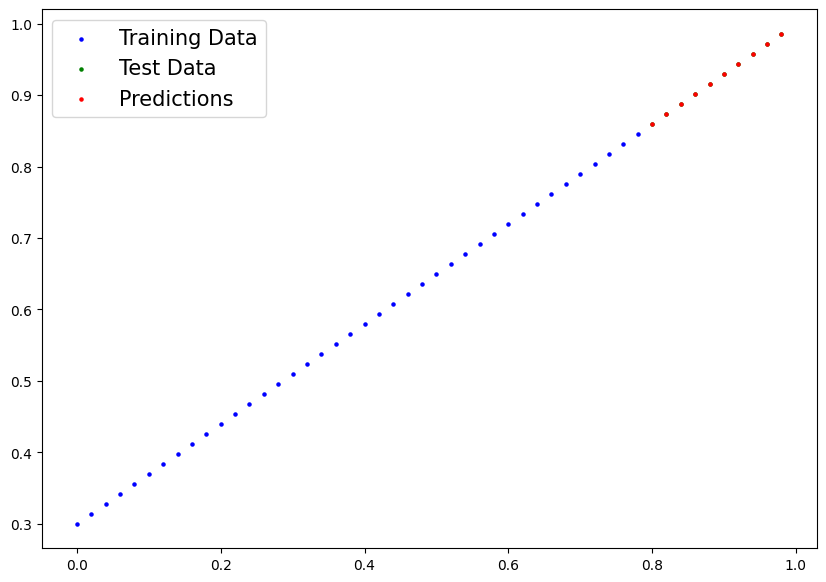

In [10]:
model_1.eval()

with torch.inference_mode():
  y_preds = model_1(X_test)

plot_prediction(prediction=y_preds)

/tmp/ipykernel_26605/1920559310.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(epoch_cnt, np.array(torch.tensor(train_loss_values).numpy()), label="Traing Loss")


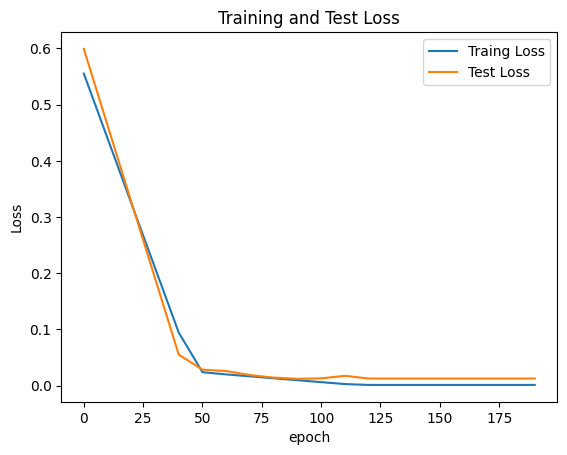

In [11]:
import numpy as np
plt.plot(epoch_cnt, np.array(torch.tensor(train_loss_values).numpy()), label="Traing Loss")
plt.plot(epoch_cnt, test_loss_values, label="Test Loss")
plt.title("Training and Test Loss")
plt.ylabel("Loss")
plt.xlabel("epoch")
plt.legend()

5. Saving and Loading the Model

In [12]:
# Saving the Model
from pathlib import Path

# Create A Model Directory
MODEL_PATH = Path("Models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#Create the Name of the Model
MODEL_NAME = "LinearRegressionModel3.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model as state_dict()
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)

In [13]:
# Loading the Model
# To Load the Model we to create an instance of the model
loaded_model = LinearRegressionModel()

# Load the Saved Model
loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

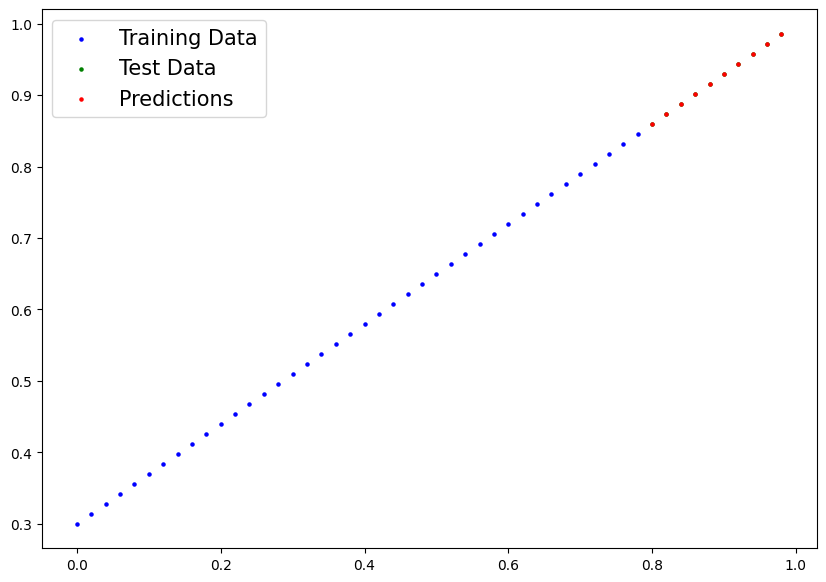

In [15]:
loaded_model.eval()

with torch.inference_mode():
  loaded_model_pred = loaded_model(X_test)

plot_prediction(prediction=loaded_model_pred)